In [1]:
from google.colab import drive #mount connect to drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
#import libraries.
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [6]:
#set datset paths
base_path = '/content/drive/MyDrive/Blood_Cell_Classification_Project/dataset/images/'

train_dir = base_path + 'TRAIN/'
val_dir   = base_path + 'TEST_SIMPLE/'
test_dir  = base_path + 'TEST/'


In [7]:
#data preprocessing
IMG_SIZE = (128,128)
BATCH = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')
val_data   = val_gen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')
test_data  = test_gen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')


Found 9997 images belonging to 4 classes.
Found 71 images belonging to 4 classes.
Found 2486 images belonging to 4 classes.


In [8]:
# build cnn model from scratch
model_scratch = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_scratch.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_scratch.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#model trained
history_scratch = model_scratch.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
249/313 ━━━━━━━━━━━━━━━━━━━━ 8:08 8s/step - accuracy: 0.2534 - loss: 1.3864

In [ ]:
#evaluate and save model
loss, acc = model_scratch.evaluate(test_data)
print(f"From Scratch Model Accuracy: {acc*100:.2f}%")

model_scratch.save('/content/drive/MyDrive/Blood_Cell_Classification_Project/blood_cell_cnn_scratch.h5')
print("✅ Model saved successfully!")


In [2]:
#transfer learning (vgg16)
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tl.summary()

history_tl = model_tl.fit(train_data, validation_data=val_data, epochs=10)
loss_tl, acc_tl = model_tl.evaluate(test_data)
print(f"Transfer Learning (VGG16) Accuracy: {acc_tl*100:.2f}%")

model_tl.save('/content/drive/MyDrive/Blood_Cell_Classification_Project/blood_cell_cnn_vgg16.h5')
print("✅ Transfer Learning model saved!")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'models' is not defined

✅ Model loaded successfully!


Saving _0_200.jpeg to _0_200.jpeg
📂 Uploaded file: _0_200.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
🩸 Predicted Cell Type: Monocyte


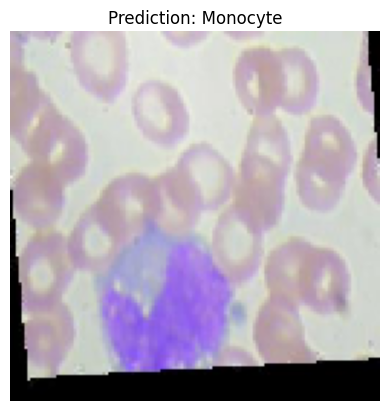

In [15]:
import tensorflow as tf
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# --- Load trained model (either scratch or VGG16) ---
model_path = '/content/drive/MyDrive/Blood_Cell_Classification_Project/blood_cell_cnn_vgg16.h5'
loaded_model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully!")

# --- Upload image ---
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
print("📂 Uploaded file:", file_path)

# --- Preprocess image ---
img = image.load_img(file_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_batch = img_batch / 255.0

# --- Predict ---
prediction = loaded_model.predict(img_batch)
pred_class = np.argmax(prediction, axis=1)[0]

class_labels = ['Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
label = class_labels[pred_class]

print(f"🩸 Predicted Cell Type: {label}")
plt.imshow(np.array(img).astype('uint8'))
plt.title(f"Prediction: {label}")
plt.axis('off')
plt.show()
